# Imports

In [9]:
import csv
import platform
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from ultralytics import YOLO

# Verificación del entorno
print(f"Python:          {platform.python_version()}")
print(f"Sistema:         {platform.system()} {platform.machine()}")
print(f"PyTorch:         {torch.__version__}")
print(f"MPS disponible:  {torch.backends.mps.is_available()}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"OpenCV:          {cv2.__version__}")
print(f"NumPy:           {np.__version__}")

Python:          3.14.4
Sistema:         Darwin arm64
PyTorch:         2.11.0
MPS disponible:  True
CUDA disponible: False
OpenCV:          4.13.0
NumPy:           2.3.5


# Carga del modelo

In [10]:
# Cargar YOLOv8n preentrenado
model = YOLO("yolov8n.pt")

# Info básica del modelo
print(f"Modelo:      {model.model_name if hasattr(model, 'model_name') else 'yolov8n'}")
print(f"Tarea:       {model.task}")
print(f"Núm. clases: {len(model.names)}")
print(f"Ejemplos de clases: {list(model.names.values())[:10]}")


Modelo:      yolov8n.pt
Tarea:       detect
Núm. clases: 80
Ejemplos de clases: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


# Modelos de inferencia disponibles

In [11]:
# Lista de modos disponibles. Cada modo = dict con name, model_path, device_arg.
modes = []

# Modo 1: CPU (siempre disponible)
modes.append({
    "name": "CPU",
    "model_path": "yolov8n.pt",
    "device_arg": "cpu",
})

# Modo 2: GPU vía MPS (Apple Silicon)
if torch.backends.mps.is_available():
    modes.append({
        "name": "MPS_GPU",
        "model_path": "yolov8n.pt",
        "device_arg": "mps",
    })

# Resumen
print("\nModos de inferencia disponibles:")
for m in modes:
    print(f"  - {m['name']:<15} (modelo: {m['model_path']})")
print(f"\nTotal: {len(modes)} modos")


Modos de inferencia disponibles:
  - CPU             (modelo: yolov8n.pt)
  - MPS_GPU         (modelo: yolov8n.pt)

Total: 2 modos


# Descarga del DataSet

COCO128 disponible en: /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets/coco128

Imágenes: 128
Labels:   128


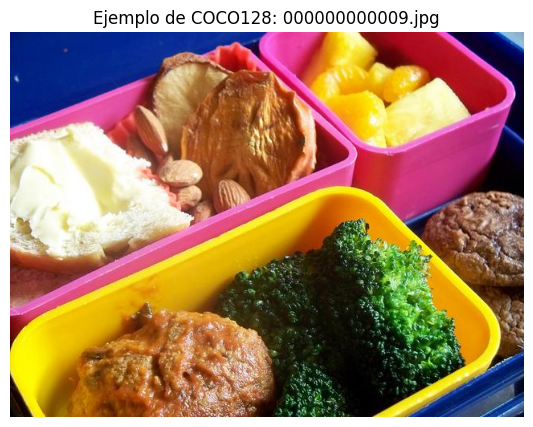


Dimensiones de la imagen ejemplo: (480, 640, 3)


In [12]:
from ultralytics import settings as ultra_settings

# Buscar COCO128 en ubicaciones posibles
def find_coco128():
    candidates = [
        Path(ultra_settings["datasets_dir"]) / "coco128",  # ubicación configurada en Ultralytics
        Path("datasets/coco128"),
        Path.home() / "datasets" / "coco128",
    ]
    for path in candidates:
        if (path / "images").exists():
            return path
    return None

coco128_path = find_coco128()

# Si no existe, disparar la descarga vía un val() mínimo
if coco128_path is None:
    print("COCO128 no encontrado. Descargando (~7 MB)...")
    model.val(data="coco128.yaml", verbose=False, plots=False, device="cpu")
    coco128_path = find_coco128()

print(f"COCO128 disponible en: {coco128_path}")

# Inspección del dataset
images_dir = coco128_path / "images" / "train2017"
labels_dir = coco128_path / "labels" / "train2017"

image_files = sorted(images_dir.glob("*.jpg"))
label_files = sorted(labels_dir.glob("*.txt"))

print(f"\nImágenes: {len(image_files)}")
print(f"Labels:   {len(label_files)}")

# Mostrar una imagen de ejemplo
example_image_path = image_files[0]
example_image = cv2.imread(str(example_image_path))
example_image_rgb = cv2.cvtColor(example_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(example_image_rgb)
plt.title(f"Ejemplo de COCO128: {example_image_path.name}")
plt.axis("off")
plt.show()

print(f"\nDimensiones de la imagen ejemplo: {example_image.shape}")

# Perturbación de imagenes con Gamma

Figura guardada en: results/gamma_examples.png


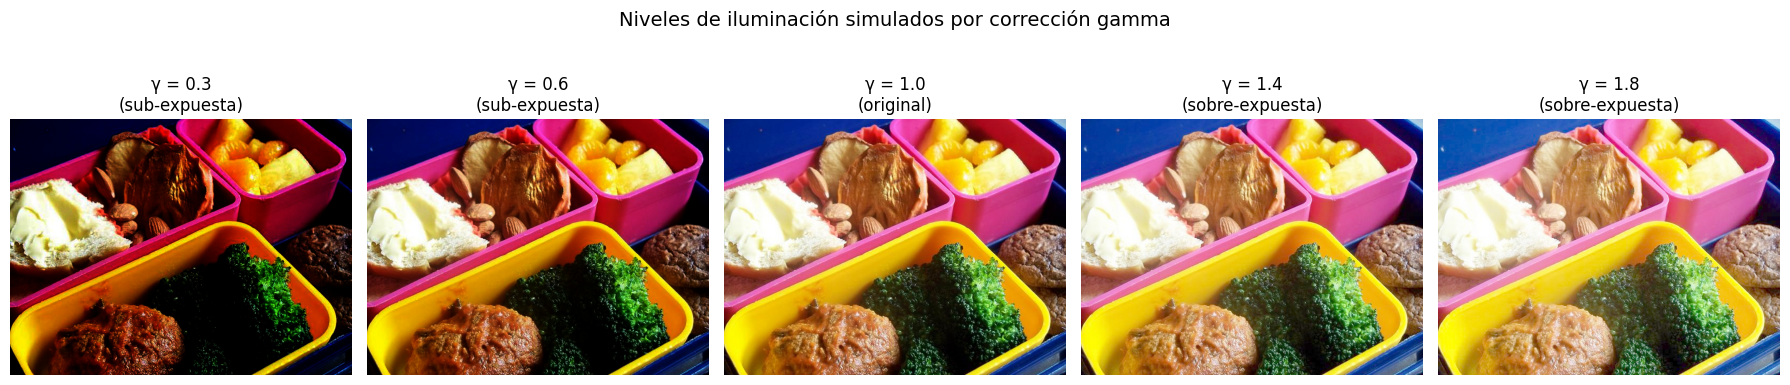

In [13]:
def apply_gamma_correction(image, gamma):
    """Aplica corrección gamma a una imagen BGR vía look-up table.

    gamma < 1.0 → la imagen se ve más oscura (menos luz disponible)
    gamma > 1.0 → la imagen se ve más clara (sobre-exposición)
    """
    inverse_gamma = 1.0 / gamma
    lookup_table = np.array([
        ((value / 255.0) ** inverse_gamma) * 255
        for value in range(256)
    ]).astype(np.uint8)
    return cv2.LUT(image, lookup_table)


GAMMA_VALUES = [0.3, 0.6, 1.0, 1.4, 1.8]

# Aplicar cada gamma a la imagen ejemplo y visualizar
fig, axes = plt.subplots(1, len(GAMMA_VALUES), figsize=(18, 4))

for ax, gamma in zip(axes, GAMMA_VALUES):
    perturbed = apply_gamma_correction(example_image, gamma)
    perturbed_rgb = cv2.cvtColor(perturbed, cv2.COLOR_BGR2RGB)
    ax.imshow(perturbed_rgb)

    if gamma == 1.0:
        title = f"γ = {gamma}\n(original)"
    elif gamma < 1.0:
        title = f"γ = {gamma}\n(sub-expuesta)"
    else:
        title = f"γ = {gamma}\n(sobre-expuesta)"

    ax.set_title(title)
    ax.axis("off")

plt.suptitle(
    "Niveles de iluminación simulados por corrección gamma",
    fontsize=14, y=1.05,
)
plt.tight_layout()

# Guardar la figura para usar en el documento
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "gamma_examples.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
print(f"Figura guardada en: {output_path}")

plt.show()

# Generación datasets perturbados

In [14]:
def build_perturbed_dataset(source_dir, gamma, target_dir):
    """Copia COCO128 a target_dir aplicando corrección gamma a las imágenes.

    Las labels permanecen idénticas porque la perturbación es solo fotométrica.
    """
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True)

    # Copiar labels sin modificar
    shutil.copytree(source_dir / "labels", target_dir / "labels")

    # Procesar imágenes
    source_images = source_dir / "images" / "train2017"
    target_images = target_dir / "images" / "train2017"
    target_images.mkdir(parents=True)

    for image_path in sorted(source_images.glob("*.jpg")):
        image = cv2.imread(str(image_path))
        perturbed = apply_gamma_correction(image, gamma)
        cv2.imwrite(str(target_images / image_path.name), perturbed)


def write_dataset_yaml(dataset_dir, yaml_path):
    """Genera un yaml apuntando al dataset perturbado.

    Reutiliza el yaml original de Ultralytics cambiando solo el campo path.
    """
    import ultralytics
    original_yaml = (
        Path(ultralytics.__file__).parent / "cfg" / "datasets" / "coco128.yaml"
    )
    yaml_text = original_yaml.read_text()

    new_lines = []
    for line in yaml_text.splitlines():
        if line.strip().startswith("path:"):
            new_lines.append(f"path: {dataset_dir.resolve()}")
        else:
            new_lines.append(line)
    yaml_path.write_text("\n".join(new_lines))


# Crear directorio de datasets perturbados (al lado del original)
datasets_root = coco128_path.parent
print(f"Directorio de datasets: {datasets_root}")

# Generar datasets perturbados para gammas != 1.0
# gamma_datasets mapea cada gamma a la ruta del yaml correspondiente
gamma_datasets = {1.0: "coco128.yaml"}  # gamma=1.0 usa el dataset original

for gamma in GAMMA_VALUES:
    if gamma == 1.0:
        continue

    print(f"\nGenerando dataset con gamma={gamma}...")
    perturbed_dir = datasets_root / f"coco128_gamma{gamma}"
    yaml_path = datasets_root / f"coco128_gamma{gamma}.yaml"

    build_perturbed_dataset(coco128_path, gamma, perturbed_dir)
    write_dataset_yaml(perturbed_dir, yaml_path)

    num_images = len(list((perturbed_dir / "images" / "train2017").glob("*.jpg")))
    gamma_datasets[gamma] = str(yaml_path)
    print(f"  → {perturbed_dir.name}: {num_images} imágenes")

print(f"\nDatasets disponibles ({len(gamma_datasets)}):")
for gamma in sorted(gamma_datasets.keys()):
    print(f"  γ = {gamma}: {gamma_datasets[gamma]}")

Directorio de datasets: /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets

Generando dataset con gamma=0.3...
  → coco128_gamma0.3: 128 imágenes

Generando dataset con gamma=0.6...
  → coco128_gamma0.6: 128 imágenes

Generando dataset con gamma=1.4...
  → coco128_gamma1.4: 128 imágenes

Generando dataset con gamma=1.8...
  → coco128_gamma1.8: 128 imágenes

Datasets disponibles (5):
  γ = 0.3: /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets/coco128_gamma0.3.yaml
  γ = 0.6: /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets/coco128_gamma0.6.yaml
  γ = 1.0: coco128.yaml
  γ = 1.4: /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets/coco128_gamma1.4.yaml
  γ = 1.8: /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets/coco128_gamma1.8.yaml


# Ejecución de los dos modos de inferencia

In [15]:
def evaluate(mode, gamma, data_yaml):
    """Evalúa un modo de inferencia con un gamma específico.

    Retorna dict con métricas, o None si la evaluación falla.
    """
    try:
        eval_model = YOLO(mode["model_path"])
        metrics = eval_model.val(
            data=data_yaml,
            verbose=False,
            plots=False,
            device=mode["device_arg"],
        )
        return {
            "mode": mode["name"],
            "gamma": gamma,
            "mAP50": float(metrics.box.map50),
            "mAP50_95": float(metrics.box.map),
            "inference_ms": float(metrics.speed["inference"]),
            "preprocess_ms": float(metrics.speed["preprocess"]),
            "postprocess_ms": float(metrics.speed["postprocess"]),
        }
    except Exception as error:
        print(f"  ERROR: {error}")
        return None


# Bucle principal: modos × gammas
results = []
total_combinations = len(modes) * len(GAMMA_VALUES)
combo_index = 0

for mode in modes:
    for gamma in GAMMA_VALUES:
        combo_index += 1
        print(f"\n[{combo_index}/{total_combinations}] {mode['name']} | γ={gamma}")

        data_yaml = gamma_datasets[gamma]
        result = evaluate(mode, gamma, data_yaml)

        if result is not None:
            print(
                f"  mAP@0.5 = {result['mAP50']:.3f}  "
                f"|  mAP@0.5:0.95 = {result['mAP50_95']:.3f}  "
                f"|  latencia = {result['inference_ms']:.1f} ms"
            )
            results.append(result)

# Guardar resultados a CSV
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
csv_path = results_dir / "metrics.csv"

with open(csv_path, "w", newline="") as f:
    fieldnames = [
        "mode", "gamma", "mAP50", "mAP50_95",
        "inference_ms", "preprocess_ms", "postprocess_ms",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"\n✓ {len(results)}/{total_combinations} evaluaciones completadas")
print(f"✓ Resultados guardados en: {csv_path}")


[1/10] CPU | γ=0.3
Ultralytics 8.4.48 🚀 Python-3.14.4 torch-2.11.0 CPU (Apple A18 Pro)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 472.1±123.5 MB/s, size: 69.2 KB)
val: Scanning /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets/coco128_gamma0.3/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 5.2Kit/s 0.0s
val: New cache created: /Users/zafika/Documents/Universidad/2026-1/Vision Por Computador/datasets/coco128_gamma0.3/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8s/it 14.4s2.1s
                   all        128        929      0.571      0.425      0.471      0.327
Speed: 0.5ms preprocess, 109.4ms inference, 0.0ms loss, 0.6ms postprocess per image
  mAP@0.5 = 0.471  |  mAP@0.5:0.95 = 0.327  |  latencia = 109.4 ms

[2/10] CPU | γ=0.6
Ultralytics 8.4.

# Visualización de resultados

✓ results/accuracy_vs_gamma.png


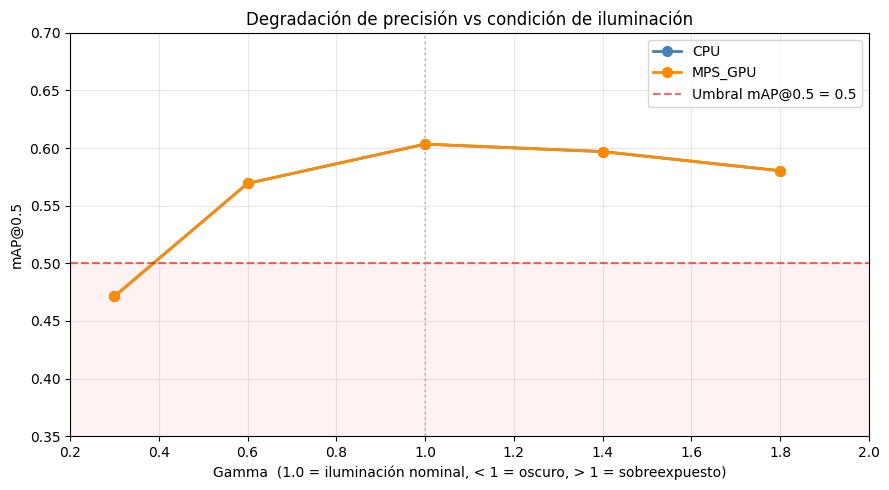

✓ results/latency_per_mode.png


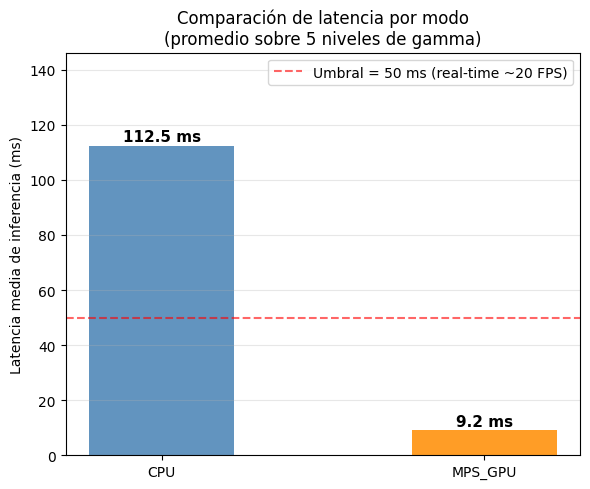

✓ results/viability_map.png


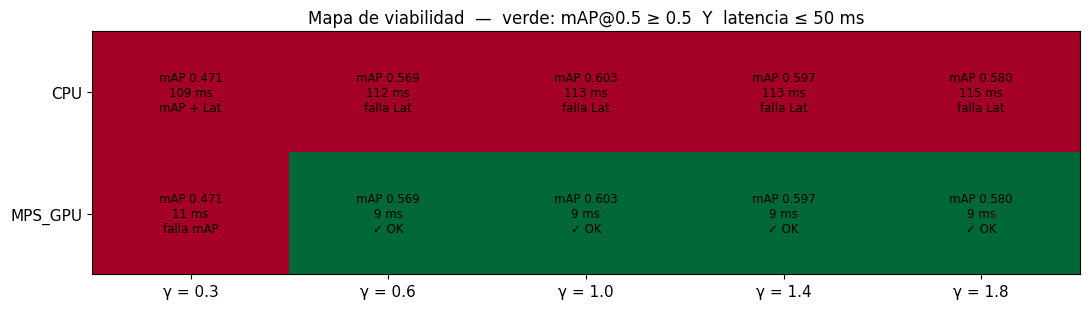

In [16]:
# Umbrales
THRESHOLD_MAP50 = 0.5
THRESHOLD_LATENCY_MS = 50

# Helpers
modes_seen = sorted(set(r["mode"] for r in results))
gammas_seen = sorted(set(r["gamma"] for r in results))
mode_colors = {"CPU": "steelblue", "MPS_GPU": "darkorange"}

def get_rows(mode_name):
    return sorted([r for r in results if r["mode"] == mode_name], key=lambda r: r["gamma"])

def is_viable(r):
    return r["mAP50"] >= THRESHOLD_MAP50 and r["inference_ms"] <= THRESHOLD_LATENCY_MS

def fail_label(r):
    map_fail = r["mAP50"] < THRESHOLD_MAP50
    lat_fail = r["inference_ms"] > THRESHOLD_LATENCY_MS
    if map_fail and lat_fail:  return "mAP + Lat"
    if map_fail:                return "falla mAP"
    if lat_fail:                return "falla Lat"
    return "✓ OK"


# ── Gráfico 1: mAP@0.5 vs Gamma ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for mode_name in modes_seen:
    rows = get_rows(mode_name)
    ax.plot(
        [r["gamma"] for r in rows],
        [r["mAP50"] for r in rows],
        marker="o", label=mode_name,
        color=mode_colors[mode_name], linewidth=2, markersize=7,
    )

ax.axhline(y=THRESHOLD_MAP50, linestyle="--", color="red", alpha=0.6,
           label=f"Umbral mAP@0.5 = {THRESHOLD_MAP50}")
ax.axvline(x=1.0, linestyle=":", alpha=0.4, color="gray")
ax.fill_between([0.2, 2.0], 0, THRESHOLD_MAP50, alpha=0.05, color="red")

ax.set_xlabel("Gamma  (1.0 = iluminación nominal, < 1 = oscuro, > 1 = sobreexpuesto)")
ax.set_ylabel("mAP@0.5")
ax.set_title("Degradación de precisión vs condición de iluminación")
ax.set_xlim(0.2, 2.0)
ax.set_ylim(0.35, 0.70)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/accuracy_vs_gamma.png", dpi=120, bbox_inches="tight")
print("✓ results/accuracy_vs_gamma.png")
plt.show()


# ── Gráfico 2: Latencia media por modo ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

mean_lats = [np.mean([r["inference_ms"] for r in get_rows(m)]) for m in modes_seen]
bars = ax.bar(modes_seen, mean_lats,
              color=[mode_colors[m] for m in modes_seen], alpha=0.85, width=0.45)

ax.axhline(y=THRESHOLD_LATENCY_MS, linestyle="--", color="red", alpha=0.6,
           label=f"Umbral = {THRESHOLD_LATENCY_MS} ms (real-time ~20 FPS)")

for bar, val in zip(bars, mean_lats):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
            f"{val:.1f} ms", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Latencia media de inferencia (ms)")
ax.set_title("Comparación de latencia por modo\n(promedio sobre 5 niveles de gamma)")
ax.set_ylim(0, max(mean_lats) * 1.3)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results/latency_per_mode.png", dpi=120, bbox_inches="tight")
print("✓ results/latency_per_mode.png")
plt.show()


# ── Gráfico 3: Mapa de viabilidad ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.2))

viability = np.zeros((len(modes_seen), len(gammas_seen)))
annotations = []

for i, mode_name in enumerate(modes_seen):
    row = []
    for j, gamma in enumerate(gammas_seen):
        match = next((r for r in results if r["mode"] == mode_name and r["gamma"] == gamma), None)
        if match:
            viability[i, j] = 1.0 if is_viable(match) else 0.0
            row.append(f"mAP {match['mAP50']:.3f}\n{match['inference_ms']:.0f} ms\n{fail_label(match)}")
        else:
            viability[i, j] = 0.5
            row.append("N/A")
    annotations.append(row)

ax.imshow(viability, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(gammas_seen)))
ax.set_xticklabels([f"γ = {g}" for g in gammas_seen], fontsize=11)
ax.set_yticks(range(len(modes_seen)))
ax.set_yticklabels(modes_seen, fontsize=11)

for i in range(len(modes_seen)):
    for j in range(len(gammas_seen)):
        ax.text(j, i, annotations[i][j], ha="center", va="center",
                color="black", fontsize=8.5)

ax.set_title(
    f"Mapa de viabilidad  —  verde: mAP@0.5 ≥ {THRESHOLD_MAP50}  Y  latencia ≤ {THRESHOLD_LATENCY_MS} ms",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("results/viability_map.png", dpi=120, bbox_inches="tight")
print("✓ results/viability_map.png")
plt.show()

# Resultados

In [19]:
# ── Tabla de resultados completa ─────────────────────────────────────────
print("=" * 68)
print("TABLA DE RESULTADOS")
print(f"Umbrales: mAP@0.5 ≥ {THRESHOLD_MAP50}  |  latencia ≤ {THRESHOLD_LATENCY_MS} ms")
print("=" * 68)
print(f"{'Modo':<12} {'γ':<6} {'mAP@0.5':<10} {'mAP@0.5:0.95':<14} {'Lat (ms)':<11} {'Viable'}")
print("-" * 68)
for r in results:
    marker = "✓ SI" if is_viable(r) else "✗ no"
    print(
        f"{r['mode']:<12} {r['gamma']:<6} {r['mAP50']:<10.3f} "
        f"{r['mAP50_95']:<14.3f} {r['inference_ms']:<11.1f} {marker}"
    )

# ── Métricas derivadas ────────────────────────────────────────────────────
baseline_cpu = next(r for r in results if r["mode"] == "CPU"     and r["gamma"] == 1.0)
baseline_mps = next(r for r in results if r["mode"] == "MPS_GPU" and r["gamma"] == 1.0)
worst_dark   = next(r for r in results if r["mode"] == "CPU"     and r["gamma"] == 0.3)
worst_bright = next(r for r in results if r["mode"] == "CPU"     and r["gamma"] == 1.8)

drop_dark   = (baseline_cpu["mAP50"] - worst_dark["mAP50"])   / baseline_cpu["mAP50"] * 100
drop_bright = (baseline_cpu["mAP50"] - worst_bright["mAP50"]) / baseline_cpu["mAP50"] * 100
speedup     = baseline_cpu["inference_ms"] / baseline_mps["inference_ms"]
viable_mps  = sum(1 for r in results if r["mode"] == "MPS_GPU" and is_viable(r))

print("=" * 68)
print(f"Archivo CSV con todos los datos: results/metrics.csv")
print("Figuras guardadas en results/: accuracy_vs_gamma.png, "
      "latency_per_mode.png, viability_map.png, gamma_examples.png")
print("=" * 68)

TABLA DE RESULTADOS
Umbrales: mAP@0.5 ≥ 0.5  |  latencia ≤ 50 ms
Modo         γ      mAP@0.5    mAP@0.5:0.95   Lat (ms)    Viable
--------------------------------------------------------------------
CPU          0.3    0.471      0.327          109.4       ✗ no
CPU          0.6    0.569      0.416          111.6       ✗ no
CPU          1.0    0.603      0.444          113.2       ✗ no
CPU          1.4    0.597      0.440          113.4       ✗ no
CPU          1.8    0.580      0.429          114.9       ✗ no
MPS_GPU      0.3    0.471      0.327          11.1        ✗ no
MPS_GPU      0.6    0.569      0.416          8.8         ✓ SI
MPS_GPU      1.0    0.603      0.444          9.1         ✓ SI
MPS_GPU      1.4    0.597      0.440          8.7         ✓ SI
MPS_GPU      1.8    0.580      0.429          8.5         ✓ SI
Archivo CSV con todos los datos: results/metrics.csv
Figuras guardadas en results/: accuracy_vs_gamma.png, latency_per_mode.png, viability_map.png, gamma_examples.png
